# **Phase 2 — Exploratory Data Analysis**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import os
from pathlib import Path # for system file paths related tasks
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.float_format", "{:.2f}".format)
np.set_printoptions(precision = 2, suppress = True)

In [3]:
ROOT_DIR = Path.cwd().parent
os.chdir(ROOT_DIR)

from src.config import Database,Reports, Figures
os.chdir(ROOT_DIR/Database)
from database_connector import engine

C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\StreamFlix-Content-Analytics


2026-09-24 23:40:48,019 - INFO - loading ENV variables...
2026-09-24 23:40:48,020 - INFO - URL CREATED!!
2026-09-24 23:40:48,021 - INFO - Creating DB Engine...
2026-09-24 23:40:48,161 - INFO - Engine Created!!


In [4]:
watch_history_data = pd.read_sql_query(
    """
    SELECT * 
    FROM watch_history;
    
    """,
    con = engine
)
watch_history_data.head()

,watch_id,subscriber_id,title_id,watch_date,device,region,content_duration_min,watch_duration_min,completion_pct,completed,watch_duration_hourse
0,2657,SUB109603,TTL205011,2025-09-28,Laptop,Europe,1107,1083.80,97.90,True,18.06
1,4763,SUB106721,TTL203006,2025-03-06,Mobile,Europe,1197,685.80,57.30,False,11.43
2,4833,SUB106476,TTL202356,2025-02-23,Mobile,Europe,195,24.00,12.30,False,0.40
3,8529,SUB109887,TTL206948,2026-04-12,Smart TV,Europe,1092,1028.20,94.20,True,17.14
4,9909,SUB106046,TTL207307,2025-07-05,Tablet,Europe,117,110.40,94.30,True,1.84


In [5]:
watch_history_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650000 entries, 0 to 649999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   watch_id               650000 non-null  int64         
 1   subscriber_id          650000 non-null  object        
 2   title_id               650000 non-null  object        
 3   watch_date             650000 non-null  datetime64[ns]
 4   device                 650000 non-null  object        
 5   region                 650000 non-null  object        
 6   content_duration_min   650000 non-null  int64         
 7   watch_duration_min     650000 non-null  float64       
 8   completion_pct         650000 non-null  float64       
 9   completed              650000 non-null  bool          
 10  watch_duration_hourse  650000 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 50.2+ MB


In [6]:
watch_history = watch_history_data.copy()
watch_history = watch_history.set_index("watch_date")
monthly_sessions = watch_history.resample("M").agg({"watch_id" : "count"})
monthly_sessions
monthly_sessions["watch_id"].sort_values(ascending = False).head(10)

watch_date
2026-05-31    224696
2026-04-30     90383
2026-03-31     55665
2026-02-28     33795
2026-01-31     27970
2025-12-31     23120
2025-11-30     19192
2025-10-31     17022
2025-09-30     14408
2025-08-31     13206
Name: watch_id, dtype: int64

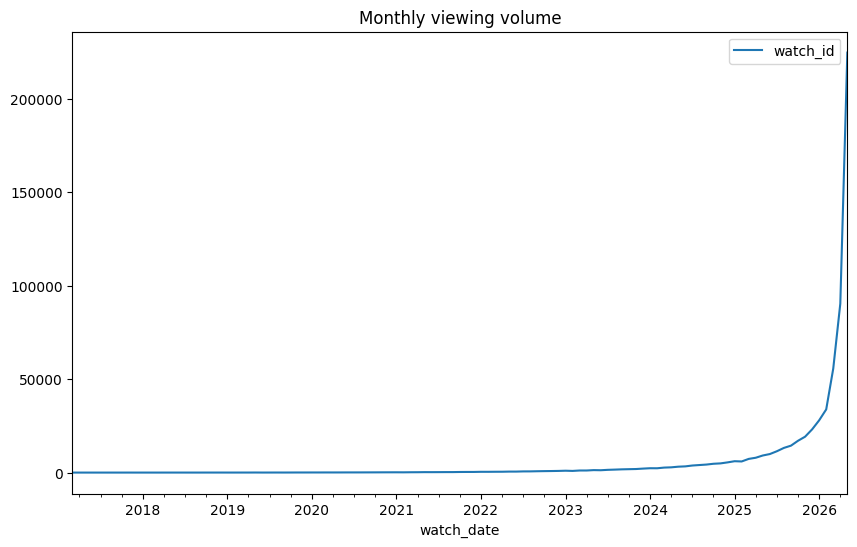

In [7]:
os.chdir(ROOT_DIR/Figures)
monthly_sessions.plot(kind='line',y= "watch_id", title='Monthly viewing volume', figsize=(10, 6))
plt.savefig("Monthly viewing volume.png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()

- **viewing volumn in 2018 to 2023 is almost constant.**
- **from 2024 to 2026, viewing trend is increasing, this suggenst, if we analyse this time frame data to know more patterns, and insight subscribers bahavoir,engagemnt with planform.** 

In [8]:
watch_history = watch_history.reset_index()
watch_history = watch_history.set_index("watch_date")
monthly_sessions = watch_history.resample("M").agg({"watch_duration_hourse" : "sum"})
monthly_sessions["watch_duration_hourse"].sort_values(ascending = False).head(10)

watch_date
2026-05-31   1157973.41
2026-04-30    463413.62
2026-03-31    286134.18
2026-02-28    174594.16
2026-01-31    143544.50
2025-12-31    118049.66
2025-11-30     98582.11
2025-10-31     85283.19
2025-09-30     71778.82
2025-08-31     66720.95
Name: watch_duration_hourse, dtype: float64

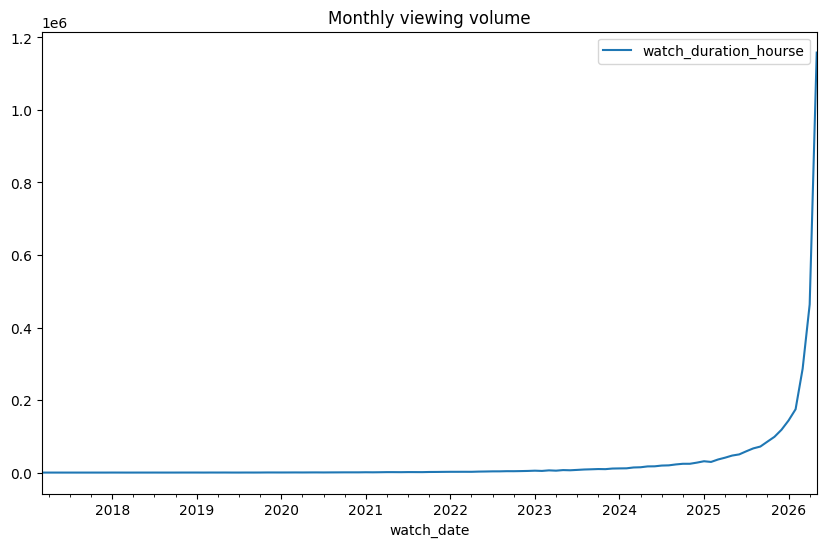

In [9]:
monthly_sessions.plot(kind='line',y= "watch_duration_hourse", title='Monthly viewing volume', figsize=(10, 6))
plt.savefig("Monthly viewing volume(watch_duration_hourse).png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()

- it clearly shows, 2024 to 2026 time frame have most of viewing sessions based on watch_duration_hourse.

In [10]:
titles_data = pd.read_sql_query(
    """
    SELECT * 
    FROM titles;
    
    """,
    con = engine
)
titles_data.head()

,title_id,title_name,type,primary_genre,country,language,release_year,date_added,maturity_rating,seasons,...,is_original,license_type,director,cast,quality_score,popularity_score,license_cost_usd,license_expiry,total_watch_hours,total_plays
0,TTL200000,Toronto Requiem,TV Show,Comedy,South Korea,Korean,2026,2026-04-05,R,6,...,True,Original,Ravi Nguyen,"Rosa Ferrari, Aria Cohen, Nina Kim, Felix Santos",68.60,0.19,7965521.00,None,1300.80,44
1,TTL200001,Seoul Inheritance,TV Show,Fantasy,South Korea,Korean,2026,2026-05-01,TV-MA,4,...,False,Non-Exclusive License,Greta Sharma,"Priya Ferrari, Lucia Mehta, Ravi Yilmaz, Joon ...",89.40,0.29,3074516.00,2028-08-03,1767.20,52
2,TTL200002,Tender Paradox,TV Show,Horror,Italy,Italian,2026,2026-04-17,PG,3,...,False,Non-Exclusive License,Bruno Moreau,"Elena Park, Aria Romano, Omar Olsen, Chloe Nak...",37.30,0.20,629307.00,2027-02-16,166.50,60
3,TTL200003,Velvet Expedition,Movie,Animation,India,Hindi,1985,2018-12-08,TV-14,0,...,False,Non-Exclusive License,Owen Mwangi,"Ava Russo, Clara Fischer, Zoe Khan, Rosa Reyes",37.80,0.02,1345769.00,2029-10-11,16.20,43
4,TTL200004,The Shadows of Lisbon,Movie,Animation,India,Hindi,1991,2016-05-11,TV-14,0,...,False,Exclusive License,Joon Kim,"Hana Patel, Fatima Patel, Hassan Reyes, Liam L...",78.00,0.00,1696493.00,2028-11-21,35.70,43


In [11]:
titles_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   title_id              9000 non-null   object        
 1   title_name            9000 non-null   object        
 2   type                  9000 non-null   object        
 3   primary_genre         9000 non-null   object        
 4   country               9000 non-null   object        
 5   language              9000 non-null   object        
 6   release_year          9000 non-null   int64         
 7   date_added            9000 non-null   datetime64[ns]
 8   maturity_rating       9000 non-null   object        
 9   seasons               9000 non-null   int64         
 10  content_duration_min  9000 non-null   int64         
 11  is_original           9000 non-null   bool          
 12  license_type          9000 non-null   object        
 13  director          

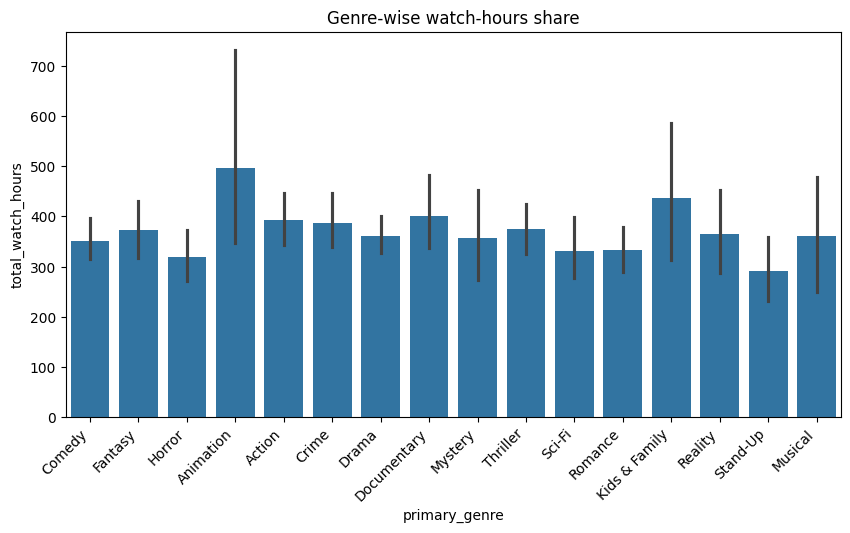

In [12]:
plt.figure(figsize = (10,5))
sns.barplot(x = titles_data["primary_genre"], y = titles_data["total_watch_hours"], errorbar = ("ci", 95))
plt.title("Genre-wise watch-hours share")
plt.xticks(rotation = 45, ha = "right")
plt.savefig("Genre-wise watch-hours share.png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()

- **genres animation, kids & family are highly viewed genres.**

In [13]:
list(titles_data["type"].unique())

['TV Show', 'Movie']

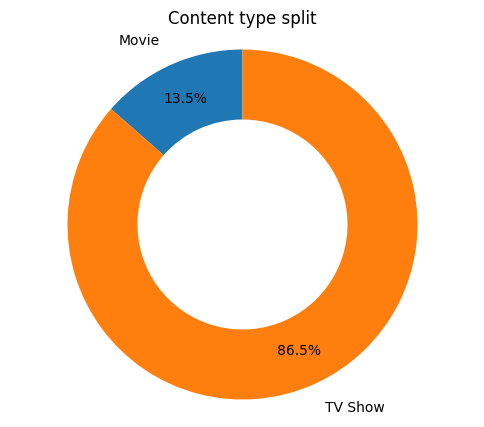

In [33]:
grouped = titles_data.groupby("type")["total_watch_hours"].sum()
plt.figure(figsize = (6,5))
plt.pie(
    grouped.values,
    labels = grouped.index,
    startangle = 90,
    autopct = "%1.1f%%",
    wedgeprops = {"width" : 0.4},
    labeldistance = 1.15,
    pctdistance = 0.79
)
plt.axis("equal")
plt.title("Content type split")
plt.savefig("Content type split.png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()

In [35]:
grouped

type
Movie      450863.00
TV Show   2882610.00
Name: total_watch_hours, dtype: float64

- **in platform, Movie related cuntent is higher about ~59% than TV Show's about ~40%**

In [15]:
country_by_watch_hr = titles_data.groupby("country")["total_watch_hours"].sum()
country_by_watch_hr.sort_values(ascending = False)

country
United States    822687.20
India            464338.30
United Kingdom   282946.70
South Korea      223477.50
Japan            207130.70
Brazil           176353.00
Mexico           157176.30
Spain            143656.40
France           115012.50
Canada           107072.00
Germany           96935.60
Turkey            82720.60
Australia         76149.50
Indonesia         71049.30
Italy             65616.20
Nigeria           63962.00
Argentina         46905.50
Thailand          46827.30
Sweden            42681.40
Egypt             40775.00
Name: total_watch_hours, dtype: float64

In [16]:
total_hrs = []
countries = []
for idx,val in enumerate(country_by_watch_hr):
    total_hrs.append(round(float(val),2))
for idx in enumerate(country_by_watch_hr.index):
    countries.append(idx[1])

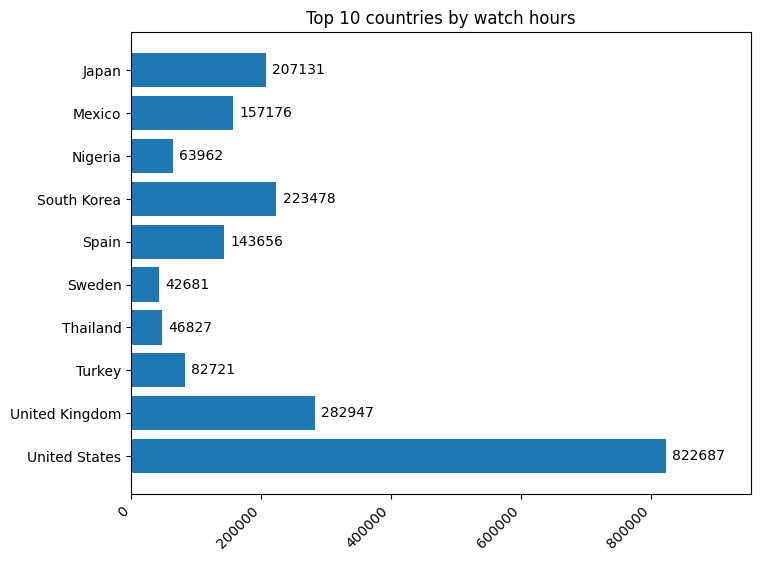

In [17]:
plt.figure(figsize = (8,6))
bars = plt.barh(countries[:-11:-1], total_hrs[:-11:-1])

for bar in bars:
    plt.text(
        bar.get_width() + 10000,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.0f}",
        va = "center",
        ha = "left"
    )
plt.xlim(0, country_by_watch_hr.max() * 1.16)
plt.title("Top 10 countries by watch hours")
plt.xticks(rotation = 45, ha = "right")
plt.savefig("Top 10 countries by watch hours.png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()

- **most of the views and sessions comes from this 10 countries about United_States,exc.**

In [18]:
subscribers_data = pd.read_sql_query(
    """
    SELECT * 
    FROM subscribers;
    
    """,
    con = engine
)
subscribers_data.head()

,subscriber_id,signup_date,country,region,age,gender,plan_type,monthly_price_usd,household_size,primary_device,payment_method,tenure_months,is_active,churn_date
0,SUB100000,2023-01-09,France,Europe,22,Female,Basic with Ads,6.99,1,Mobile,Credit Card,41,True,None
1,SUB100001,2020-02-05,United Kingdom,Europe,48,Male,Basic with Ads,6.99,1,Smart TV,Credit Card,76,False,2022-12-08
2,SUB100002,2022-04-15,Italy,Europe,35,Male,Standard,15.49,2,Streaming Stick,Gift Card,50,True,None
3,SUB100003,2024-10-10,Spain,Europe,49,Female,Basic with Ads,6.99,1,Laptop,Credit Card,19,True,None
4,SUB100004,2020-04-12,United States,North America,36,Female,Basic with Ads,6.99,1,Mobile,Credit Card,74,False,2021-12-15


In [19]:
plan_count = []
plan_type = subscribers_data.plan_type.value_counts().index.to_list()
for val in subscribers_data.plan_type.value_counts().values:
    plan_count.append(round(float(val),2))

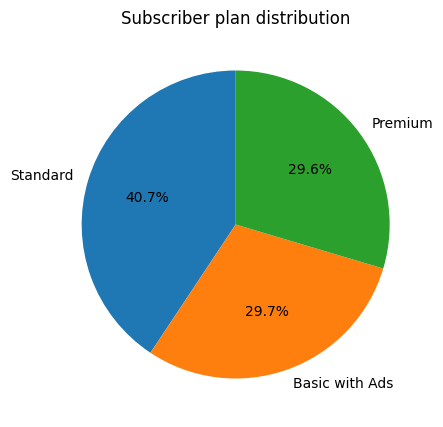

In [20]:
plt.figure(figsize = (6,5))
plt.pie(
    plan_count, 
    labels = plan_type,
    autopct = "%1.1f%%",
    startangle = 90
)
plt.title("Subscriber plan distribution")
plt.savefig("Subscriber plan distribution.png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()

In [21]:
subscribers_data.primary_device.value_counts()
device_count = []
primary_device = subscribers_data.primary_device.value_counts().index.to_list()
for val in subscribers_data.primary_device.value_counts().values:
    device_count.append(round(float(val),2))

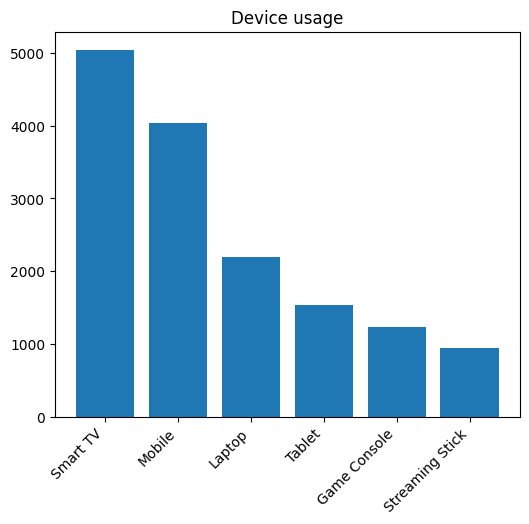

In [22]:
plt.figure(figsize = (6,5))
plt.bar(
    primary_device, 
    device_count
)
plt.title("Device usage")
plt.xticks(rotation = 45, ha = "right")
plt.savefig("Device usage.png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()

In [23]:
subscribers_data.describe()

,signup_date,age,monthly_price_usd,household_size,tenure_months
count,15000,15000.00,15000.00,15000.00,15000.00
mean,2022-09-06 21:09:01.440000,35.62,15.18,1.66,44.97
min,2016-01-13 00:00:00,13.00,6.99,1.00,1.00
25%,2020-10-17 00:00:00,27.00,6.99,1.00,18.00
50%,2023-01-25 00:00:00,35.00,15.49,1.00,40.00
75%,2024-11-24 00:00:00,44.00,22.99,2.00,68.00
max,2026-05-31 00:00:00,85.00,22.99,4.00,126.00
std,NaN,12.53,6.17,0.91,31.39


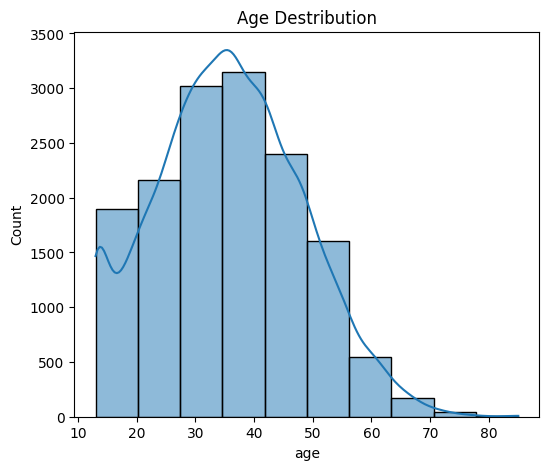

In [24]:
plt.figure(figsize = (6,5))
sns.histplot(x = subscribers_data["age"], bins = 10, kde = True)
plt.title("Age Destribution")
plt.savefig("Age Destribution.png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()

In [25]:
watch_history.head()

,watch_id,subscriber_id,title_id,device,region,content_duration_min,watch_duration_min,completion_pct,completed,watch_duration_hourse
watch_date,,,,,,,,,,
2025-09-28,2657,SUB109603,TTL205011,Laptop,Europe,1107,1083.80,97.90,True,18.06
2025-03-06,4763,SUB106721,TTL203006,Mobile,Europe,1197,685.80,57.30,False,11.43
2025-02-23,4833,SUB106476,TTL202356,Mobile,Europe,195,24.00,12.30,False,0.40
2026-04-12,8529,SUB109887,TTL206948,Smart TV,Europe,1092,1028.20,94.20,True,17.14
2025-07-05,9909,SUB106046,TTL207307,Tablet,Europe,117,110.40,94.30,True,1.84


In [26]:
title_watch_history_data = watch_history.merge(titles_data, on = "title_id", how = "left")
title_watch_history_data

,watch_id,subscriber_id,title_id,device,region,content_duration_min_x,watch_duration_min,completion_pct,completed,watch_duration_hourse,...,is_original,license_type,director,cast,quality_score,popularity_score,license_cost_usd,license_expiry,total_watch_hours,total_plays
0,2657,SUB109603,TTL205011,Laptop,Europe,1107,1083.80,97.90,True,18.06,...,False,Non-Exclusive License,Felix Romano,"Bruno Reyes, Joon Olsen, Asha Novak, Idris Moreau",75.80,0.08,1110258.00,2027-03-01,677.00,49
1,4763,SUB106721,TTL203006,Mobile,Europe,1197,685.80,57.30,False,11.43,...,False,Exclusive License,Ravi Reyes,"Noah Nakamura, Owen Lindqvist, Amara Mehta, Sa...",60.60,0.14,1153287.00,2029-02-17,643.90,48
2,4833,SUB106476,TTL202356,Mobile,Europe,195,24.00,12.30,False,0.40,...,False,Non-Exclusive License,Marco Moreau,"Clara Haddad, Nadia Garcia, Joon Kowalski, Idr...",57.50,21.65,986300.00,2027-03-06,1891.60,953
3,8529,SUB109887,TTL206948,Smart TV,Europe,1092,1028.20,94.20,True,17.14,...,False,Exclusive License,Diego Larsen,"Aria Park, Dimitri Lindqvist, Tomas Abara, Aki...",69.40,0.10,1459547.00,2028-07-08,675.90,54
4,9909,SUB106046,TTL207307,Tablet,Europe,117,110.40,94.30,True,1.84,...,False,Exclusive License,Diego Dubois,"Felix Petrov, Chloe Garcia, Nina Garcia, Nina ...",57.10,1.95,1860054.00,2027-05-04,139.90,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649995,649996,SUB113946,TTL207486,Mobile,Europe,444,8.60,1.90,False,0.14,...,False,Co-Production,Leila Vega,"Priya Lindqvist, Elena Mwangi, Felix Schmidt, ...",52.90,0.01,677179.00,2026-01-25,170.90,41
649996,649997,SUB108172,TTL200072,Smart TV,Latin America,420,338.30,80.50,False,5.64,...,False,Non-Exclusive License,Chloe Abara,"Joon Petrov, Owen Costa, Amara Silva, Sofia Patel",57.70,0.12,4173197.00,2030-02-16,193.60,44
649997,649998,SUB108092,TTL204011,Streaming Stick,South Asia,261,47.40,18.20,False,0.79,...,False,Non-Exclusive License,Idris Garcia,"Dimitri Garcia, Ava Lindqvist, Rosa Novak, Lia...",41.70,0.08,2204473.00,2029-12-02,115.20,49
649998,649999,SUB114820,TTL204762,Tablet,North America,77,11.60,15.00,False,0.19,...,True,Original,Noah Lindqvist,"Isaac Park, Noah Petrov, Amara Cohen, Tomas Pe...",41.70,0.29,2932518.00,None,39.30,58


In [27]:
agg_data = title_watch_history_data.groupby("primary_genre")["completion_pct"].sum()

In [28]:
agg_data

primary_genre
Action          5010006.30
Animation       1938930.70
Comedy          5516291.00
Crime           2890312.50
Documentary     3763472.60
Drama           6225521.00
Fantasy         1742018.90
Horror          1835228.60
Kids & Family   1197641.20
Musical          496248.30
Mystery         1184913.00
Reality         1239588.90
Romance         2873858.10
Sci-Fi          2181510.70
Stand-Up         530093.60
Thriller        3826326.00
Name: completion_pct, dtype: float64

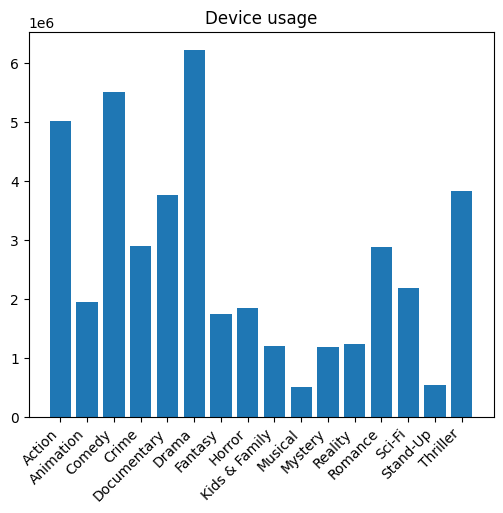

In [29]:
completion_rates = []
for val in agg_data.values:
    completion_rates.append(round(float(val),2))

plt.figure(figsize = (6,5))
plt.bar(
    agg_data.index.to_list(), 
    completion_rates
)
plt.title("Device usage")
plt.xticks(rotation = 45, ha = "right")
plt.savefig("Device usage.png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()

In [30]:
reviews_data = pd.read_sql_query(
    """
    SELECT * 
    FROM reviews;
    
    """,
    con = engine
)
reviews_data.head()

,review_id,subscriber_id,title_id,review_text,sentiment,helpful_votes,review_date
0,1,SUB102409,TTL206425,Stellar cast and a satisfying ending.,Positive,9,2023-11-04
1,2,SUB111270,TTL203987,Predictable plot and flat characters.,Negative,4,2026-04-25
2,3,SUB107848,TTL203235,"Started strong, lost steam in the middle.",Neutral,2,2024-07-31
3,4,SUB114501,TTL200930,Beautifully shot and emotionally resonant.,Positive,14,2022-12-13
4,5,SUB113370,TTL207141,A rare gem. Highly recommend.,Positive,6,2025-10-09


In [31]:
sentiment_count = []
primary_device = reviews_data.sentiment.value_counts().index.to_list()
for val in reviews_data.sentiment.value_counts().values:
    sentiment_count.append(round(float(val),2))

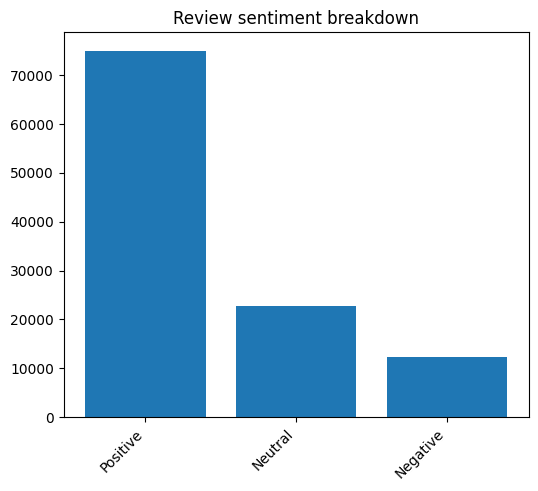

In [32]:
plt.figure(figsize = (6,5))
plt.bar(
    primary_device, 
    sentiment_count
)
plt.title("Review sentiment breakdown")
plt.xticks(rotation = 45, ha = "right")
plt.savefig("Review sentiment breakdown.png", dpi = 300, bbox_inches  = "tight", facecolor = "lightgray")
plt.show()